# DoorDash ETA Marketplace Data Loading and Processing

This notebook follows the plan in the README to load, preview, and process the dataset.

## 1. Import Required Libraries

This section imports the basic libraries for data analysis and visualization.

In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid")

## 2. Read Project Plan from README

This section reads the README file and extracts the project plan section for reference.

In [2]:
# Read the README file and display the project plan section
with open('README.md', 'r', encoding='utf-8') as f:
    readme_lines = f.readlines()

# Extract the plan section (e.g., "Modeling Plan")
plan_start = None
plan_end = None
for idx, line in enumerate(readme_lines):
    if 'Modeling Plan' in line:
        plan_start = idx
    if plan_start is not None and ('Hypothesis Testing' in line or 'Anticipated Obstacles' in line):
        plan_end = idx
        break

if plan_start is not None and plan_end is not None:
    plan_content = ''.join(readme_lines[plan_start:plan_end])
    print(plan_content)
else:
    print('Plan section not found in README.')

# Modeling Plan
Our primary task is a regression problem, where the target variable is:
Delivery duration (in seconds)
 (calculated from created_at to actual_delivery_time)
Duration = actual_delivery_time - created_at
We plan to:
Start with a baseline linear regression model
Then experiment with a tree-based model such as Random Forest
We will incorporate features such as:
Time-based features (hour of day, day of week)
Order complexity (number of items, subtotal, etc.)
Store characteristics (category)
Marketplace conditions (busy dashers, outstanding orders)
Precomputed duration estimates provided in the dataset
We will evaluate model performance using metrics such as RMSE and MAE.
We will split the dataset into training and test sets (e.g., 80/20) and use cross-validation where appropriate to ensure robust evaluation.
Phase
Model
Purpose
Baseline
OLS Linear Regression
Establish a performance floor and check for feature collinearity.
Advanced
XGBoost / LightGBM
Capture non-linear relat

## 3. Load and Preview Data

This section loads the historical_data.csv file and displays the basic structure and first few rows of the data.

In [3]:
# Read the data file
csv_path = 'Dataset File/historical_data.csv'
df = pd.read_csv(csv_path)

# Show basic info and first few rows of the data
print('Data shape:', df.shape)
display(df.head())
display(df.info())

Data shape: (197428, 16)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

None

## 4. Data Processing According to Plan

This section performs initial data processing as described in the README plan, including missing value statistics, time format conversion, calculation of delivery duration, and basic feature visualization.

Missing value count by column:


total_busy_dashers                              16262
total_outstanding_orders                        16262
total_onshift_dashers                           16262
store_primary_category                           4760
order_protocol                                    995
market_id                                         987
estimated_store_to_consumer_driving_duration      526
actual_delivery_time                                7
dtype: int64

Sample of new delivery_duration column:


,created_at,actual_delivery_time,delivery_duration
0,2015-02-06 22:24:17,2015-02-06 23:27:16,3779.0
1,2015-02-10 21:49:25,2015-02-10 22:56:29,4024.0
2,2015-01-22 20:39:28,2015-01-22 21:09:09,1781.0
3,2015-02-03 21:21:45,2015-02-03 22:13:00,3075.0
4,2015-02-15 02:40:36,2015-02-15 03:20:26,2390.0


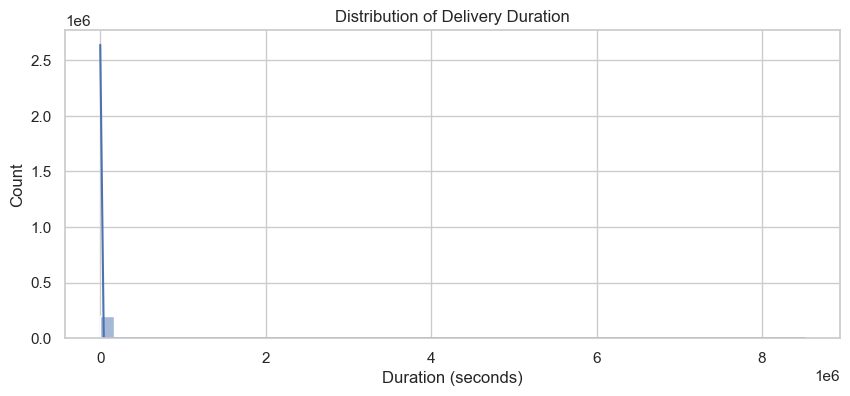

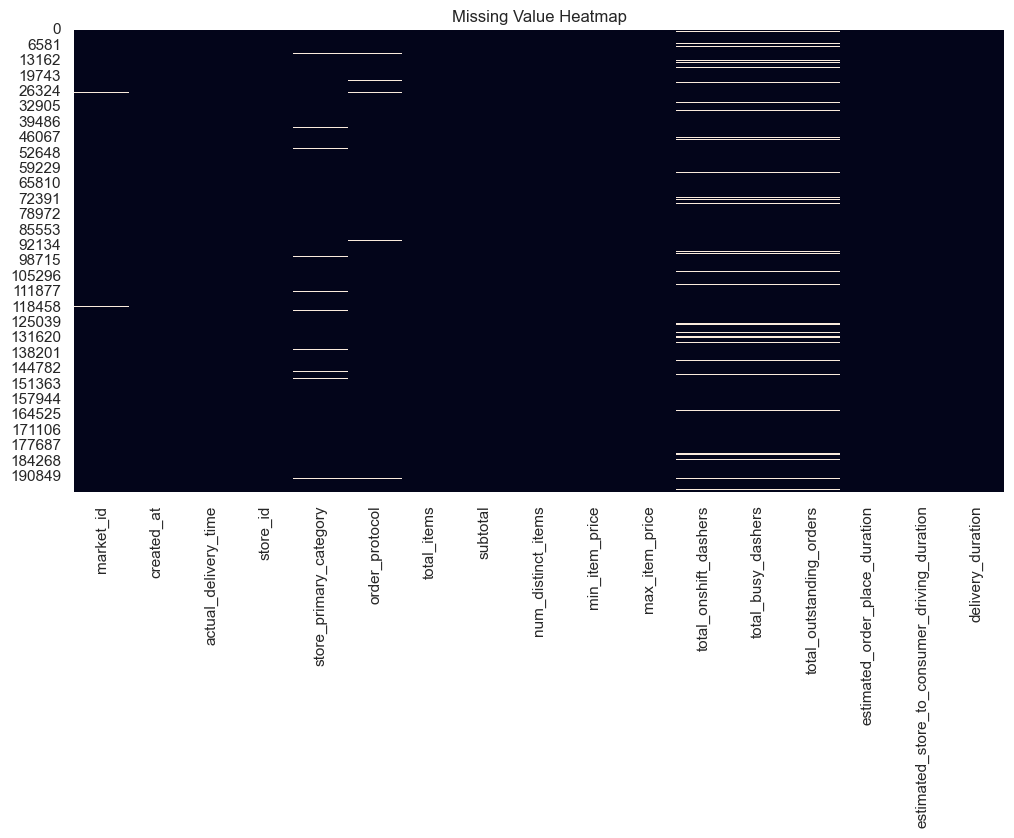

In [4]:
# Missing value statistics
missing = df.isnull().sum().sort_values(ascending=False)
print('Missing value count by column:')
display(missing[missing > 0])

# Convert time columns to datetime
for col in ['created_at', 'actual_delivery_time']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculate target variable: delivery_duration (in seconds)
if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()
    print('Sample of new delivery_duration column:')
    display(df[['created_at', 'actual_delivery_time', 'delivery_duration']].head())

# Visualize distribution of delivery_duration
plt.figure(figsize=(10,4))
sns.histplot(df['delivery_duration'].dropna(), bins=50, kde=True)
plt.title('Distribution of Delivery Duration')
plt.xlabel('Duration (seconds)')
plt.show()

# Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Value Heatmap')
plt.show()